In [1]:
#Checking: is Takahashi prediction usually lower or higher under varying cone angles?

import pandas as pd
import numpy as np
import datetime as dt
import glob

#from heatmap_plotting_modules import CA_MA_Binned_Plot, CA_Error_Plot

##load Cluster CSVs

cl_file_list = []

path = "/Users/roseatkinson/Documents/Cluster_Int_CSVs/**"

for path in glob.glob(path, recursive=True):
    if '.csv' in path:
        cl_file_list.append(path)
    
cl_dfs = []

for file in cl_file_list:
    df = pd.read_csv(file,encoding='utf-8')
    df['datetime'] = pd.to_datetime(df['datetime'], format='mixed')
    df.set_index('datetime', inplace = True)
    cl_dfs.append(df)

cl_power_all = pd.concat(cl_dfs)

print("dfs loaded in")

#Filtering: remove times when OMNI source sc was too far from X-line, & current sheets, & filter down to -5<Zgipm<5 "plane"
cl_filtered = cl_power_all.loc[(cl_power_all['OMNI Dist from X line (mean)'] < 70) & (cl_power_all['Max IMF Deviation'] < 60)]
cl_filtered_lowZ = cl_filtered.loc[(cl_filtered['GIPM Z (OMNI mean)'] < 5) & (cl_filtered['GIPM Z (OMNI mean)'] > -5)]

#add a row normalised by OMNI mag field average... I should be doing this at the source really.
cl_filtered_lowZ['Normalised Transverse Frequency'] = (cl_filtered_lowZ['Peak Transverse Frequency']/cl_filtered_lowZ['IMF B (mean)'])
cl_filtered_lowZ['Normalised Compressive Frequency'] = (cl_filtered_lowZ['Peak Compressive Frequency']/cl_filtered_lowZ['IMF B (mean)'])

#Add a row with the Takahashi and Heilig predictions

#Takahashi prefactor
pi = np.pi
m_p = 1.67E-27
q_p = 1.60E-19
takahashi_pref = q_p/(4*pi*m_p)

cl_filtered_lowZ['Takahashi Frequency, Hz'] = 1E-9*takahashi_pref*(cl_filtered_lowZ['IMF B (mean)'])*(np.cos(np.deg2rad(cl_filtered_lowZ['cone angle (mean)'])))**2
cl_filtered_lowZ['Heilig Frequency, Hz'] = 1E-3*(0.78*cl_filtered_lowZ['M_A (mean)'] + 0.64)*cl_filtered_lowZ['IMF B (mean)']

cl_filtered_lowZ['Takahashi Transverse Error/Measurement Resolution'] = (cl_filtered_lowZ['Takahashi Frequency, Hz'] - cl_filtered_lowZ['Peak Transverse Frequency'])/0.004166666666666667
cl_filtered_lowZ['Takahashi Compressive Error/Measurement Resolution'] = (cl_filtered_lowZ['Takahashi Frequency, Hz'] - cl_filtered_lowZ['Peak Compressive Frequency'])/0.004166666666666667
cl_filtered_lowZ['Heilig Transverse Error/Measurement Resolution'] = (cl_filtered_lowZ['Heilig Frequency, Hz'] - cl_filtered_lowZ['Peak Transverse Frequency'])/0.004166666666666667

cl_filtered_lowZ['Takahashi Transverse Error'] = (cl_filtered_lowZ['Takahashi Frequency, Hz'] - cl_filtered_lowZ['Peak Transverse Frequency'])/cl_filtered_lowZ['Peak Transverse Frequency']
cl_filtered_lowZ['Takahashi Compressive Error'] = (cl_filtered_lowZ['Takahashi Frequency, Hz'] - cl_filtered_lowZ['Peak Compressive Frequency'])/cl_filtered_lowZ['Peak Compressive Frequency']
cl_filtered_lowZ['Heilig Transverse Error'] = (cl_filtered_lowZ['Heilig Frequency, Hz'] - cl_filtered_lowZ['Peak Transverse Frequency'])/cl_filtered_lowZ['Peak Transverse Frequency']

cl_filtered_lowZ['Takahashi Transverse Difference'] = (cl_filtered_lowZ['Takahashi Frequency, Hz'] - cl_filtered_lowZ['Peak Transverse Frequency'])
cl_filtered_lowZ['Takahashi Compressive Difference'] = (cl_filtered_lowZ['Takahashi Frequency, Hz'] - cl_filtered_lowZ['Peak Compressive Frequency'])
cl_filtered_lowZ['Heilig Transverse Difference'] = (cl_filtered_lowZ['Heilig Frequency, Hz'] - cl_filtered_lowZ['Peak Transverse Frequency'])

#Split only by cone angle, not M_A

CA_bounds_narrow = {"rad": [0,30], "lowspir": [30,45], "highspir": [45,60],"lowperp": [60,75], "highperp": [75,90]}

#filter by cone angle and mach no:

def ca_filter(ca_lims):
    ca_filt = cl_filtered_lowZ.loc[(cl_filtered_lowZ['cone angle (mean)'] >= ca_lims[0]) & (cl_filtered_lowZ['cone angle (mean)'] < ca_lims[1])]
    return(ca_filt)

CA_filtered_frames = {}

for ca_key, ca_bounds in CA_bounds_narrow.items():
    CA_filtered_frames[ca_key] = ca_filter(ca_bounds)

print("CA-only filtered")

dfs loaded in
CA-only filtered


In [2]:
#updated to include heatmaps, with bins w/ under 50 obs removed.
from heatmap_plotting_modules import CA_Abs_Error_Plot

x_bin_edges = range(20)
y_bin_edges = range(-20, 20)


histograms = []
takahashi_trans_error_heatmap = []

for group_name, df in CA_filtered_frames.items():
    #print(group_name)
    histogram, takahashi_trans_error_hm, _,_ = compute_res_error_hists(df)
    histograms.append(histogram)
    takahashi_trans_error_heatmap.append(takahashi_trans_error_hm)

filtered_heatmap_c = []
#set all non-NaN values to 1.5 for mapping purposes
for heatmap in takahashi_trans_error_heatmap:
    heatmap[np.isnan(heatmap) == False] = 1.5
    filtered_heatmap_c.append(heatmap)
    #print(heatmap)

# #now with SW filtered
# #filter for ONLY likely ULF waves (power >0.05):

# histograms_ULF = []
# takahashi_trans_error_heatmap_ULF = []
# takahashi_comp_error_heatmap_ULF = []
# heilig_trans_error_heatmap_ULF = []

# for group_name, df in CA_filtered_frames.items():
#     #filtering for ULF wave power
#     df_ULF = df.loc[(df['ULF Band Normalised Transverse Power'] > 0.05)]
#     histogram, takahashi_trans_error_hm, takahashi_comp_error_hm, heilig_trans_error_hm = compute_res_error_hists(df_ULF)
#     histograms_ULF.append(histogram)
#     takahashi_trans_error_heatmap_ULF.append(takahashi_trans_error_hm)
#     takahashi_comp_error_heatmap_ULF.append(takahashi_comp_error_hm)
#     heilig_trans_error_heatmap_ULF.append(heilig_trans_error_hm)


# CA_Abs_Error_Plot('Takahashi Transverse Error Over Resolution, SW Filtered', takahashi_trans_error_heatmap_ULF, filtered_heatmap_c , x_bin_edges, y_bin_edges)
# CA_Abs_Error_Plot('Takahashi Compressive Error Over Resolution, SW Filtered', takahashi_comp_error_heatmap_ULF, filtered_heatmap_c , x_bin_edges, y_bin_edges)
# CA_Abs_Error_Plot('Heilig Transverse Error Over Resolution, SW Filtered', heilig_trans_error_heatmap_ULF, filtered_heatmap_c , x_bin_edges, y_bin_edges)


NameError: name 'compute_res_error_hists' is not defined

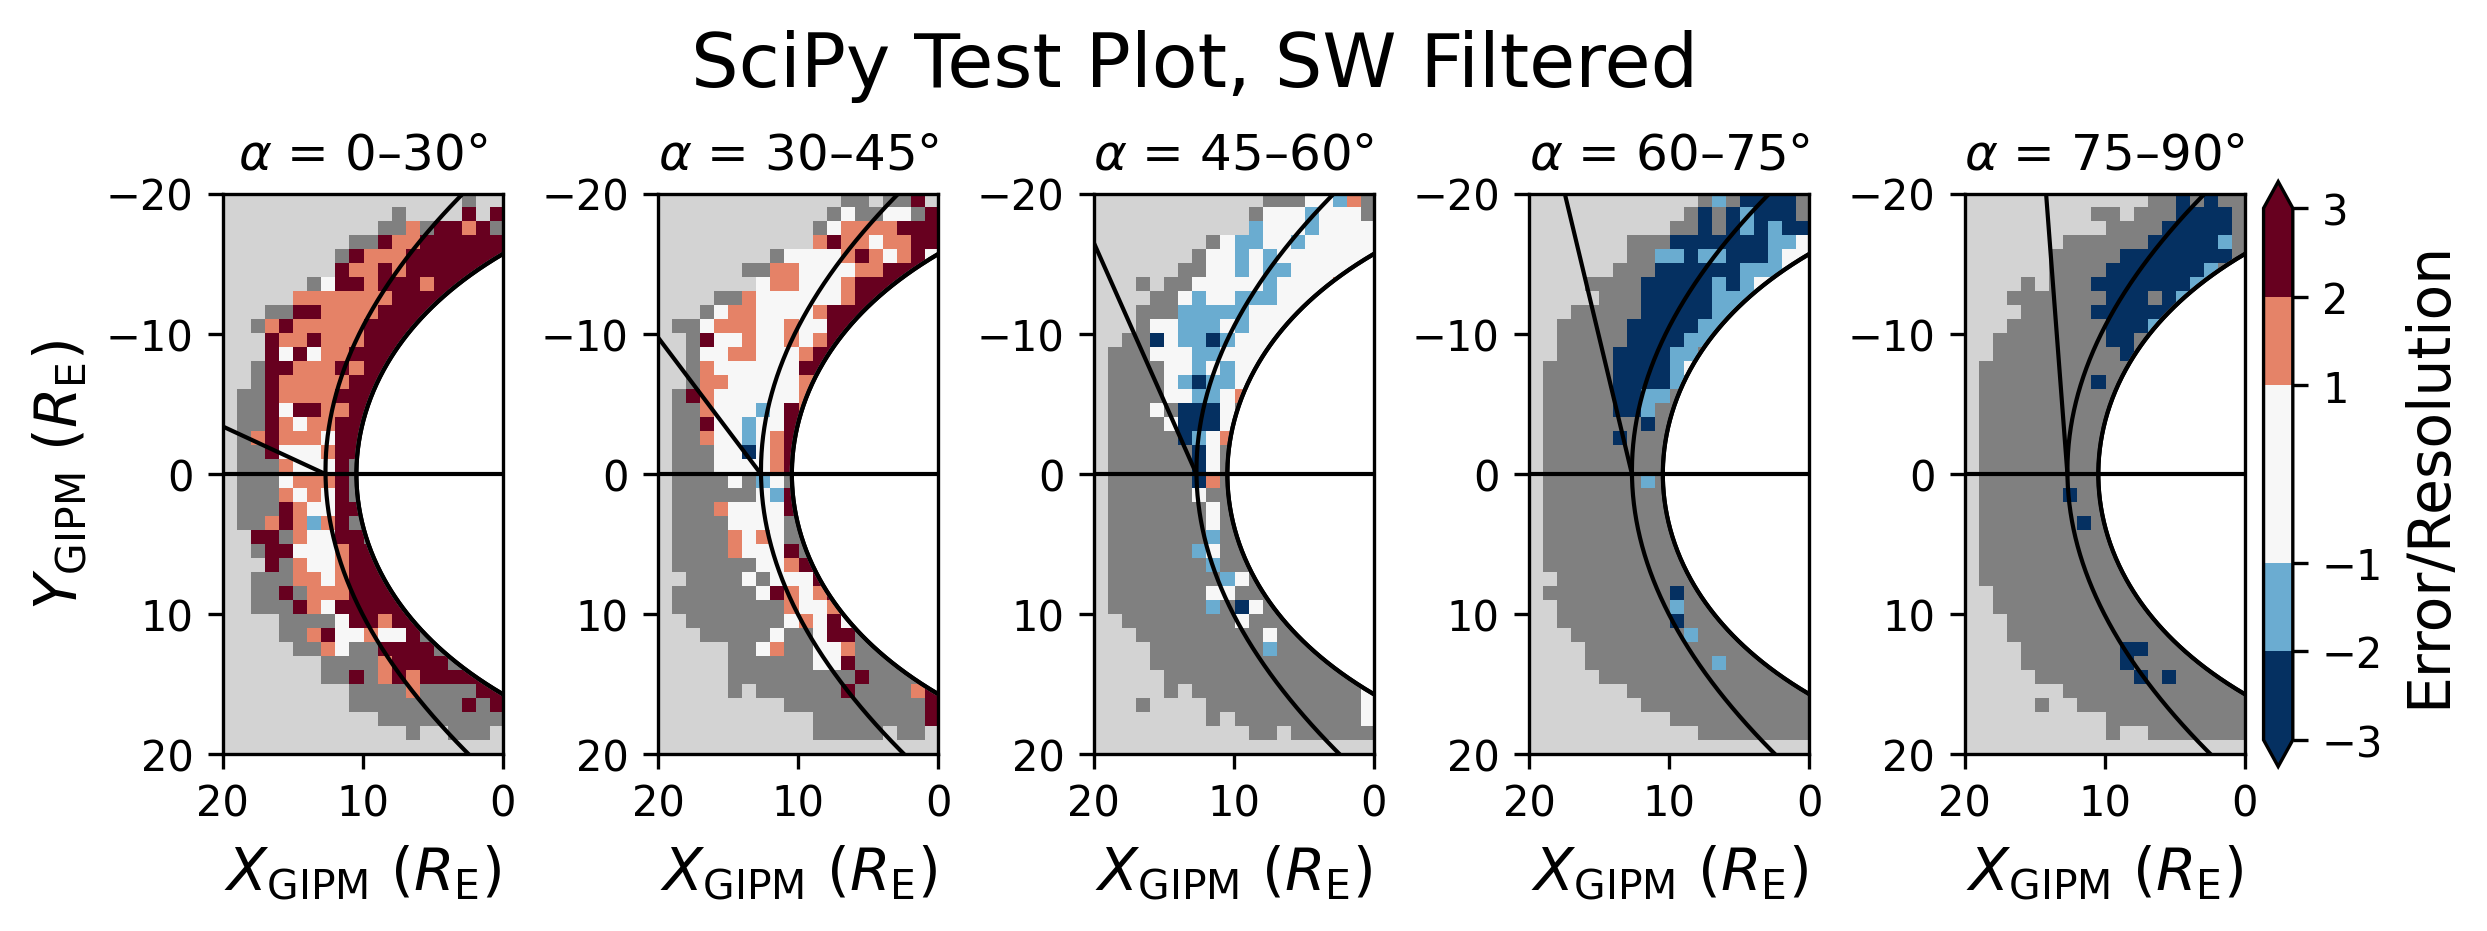

In [3]:
#also produce standard error plot
#use scipy for this

from scipy import stats
from heatmap_plotting_modules import CA_Error_Plot

x_bin_edges = range(20)
y_bin_edges = range(-20, 20)

x_col='GIPM X (OMNI mean)'
y_col='GIPM Y (OMNI mean)'
w_test='Takahashi Transverse Error/Measurement Resolution'
cl_filtered_lowZ

test_hms = []

#filter for 50 dfs

for group_name, df in CA_filtered_frames.items():
    hist_count,x_edge, y_edge, _ = stats.binned_statistic_2d(df[x_col].to_numpy(), df[y_col].to_numpy(), df[w_test].to_numpy(), statistic='count', bins=[x_bin_edges, y_bin_edges])
    hist_count[hist_count < 50] = np.nan
    hist_test,x_edge, y_edge, _ = stats.binned_statistic_2d(df[x_col].to_numpy(), df[y_col].to_numpy(), df[w_test].to_numpy(), statistic='mean', bins=[x_bin_edges, y_bin_edges])
    hist_new = np.where(np.isnan(hist_count), np.nan, hist_test)
    hist_new = hist_new.T
    test_hms.append(hist_new)

#CA_Error_Plot('Test Plot', test_hms, x_edge, y_edge)

######now with SW filtered

#produce filtered hm to mark sw vs background

filtered_heatmap_c = []
#set all non-NaN values to 1.5 for mapping purposes
for heatmap in test_hms:
    heatmap[np.isnan(heatmap) == False] = 1.5
    filtered_heatmap_c.append(heatmap)
    #print(heatmap)

takahashi_trans_error_heatmap_ULF_test = []

for group_name, df in CA_filtered_frames.items():
    #print(group_name)
    df_ULF = df.loc[(df['ULF Band Normalised Transverse Power'] > 0.05)]
    hist_count,x_edge, y_edge, _ = stats.binned_statistic_2d(df_ULF[x_col].to_numpy(), df_ULF[y_col].to_numpy(), df_ULF[w_test].to_numpy(), statistic='count', bins=[x_bin_edges, y_bin_edges])
    hist_count[hist_count < 50] = np.nan
    hist_test,x_edge, y_edge, _ = stats.binned_statistic_2d(df_ULF[x_col].to_numpy(), df_ULF[y_col].to_numpy(), df_ULF[w_test].to_numpy(), statistic='mean', bins=[x_bin_edges, y_bin_edges])
    hist_new = np.where(np.isnan(hist_count), np.nan, hist_test)
    hist_new = hist_new.T
    takahashi_trans_error_heatmap_ULF_test.append(hist_new)

#hist_test = stats.binned_statistic_2d(df[x_col].to_numpy(), df[y_col].to_numpy(), df[w_transverse].to_numpy(), statistic='mean', bins=[x_bin_edges, y_bin_edges])
#hist = stats.binned_statistic_2d(df[x_col].to_numpy(), df[y_col].to_numpy(), df[w_transverse].to_numpy(), statistic='std', bins=[binx, biny])

#does this have the same rotation as np hist2d? test

CA_Abs_Error_Plot('SciPy Test Plot, SW Filtered', takahashi_trans_error_heatmap_ULF_test, filtered_heatmap_c , x_bin_edges, y_bin_edges)

In [4]:
#now for filtered SW, find std dev in each bin:

trans_std_dev_maps = []
w_transverse='Normalised Transverse Frequency'

for group_name, df in CA_filtered_frames.items():
    #print(group_name)
    df_ULF = df.loc[(df['ULF Band Normalised Transverse Power'] > 0.05)]
    hist_count,x_edge, y_edge, _ = stats.binned_statistic_2d(df_ULF[x_col].to_numpy(), df_ULF[y_col].to_numpy(), df_ULF[w_transverse].to_numpy(), statistic='count', bins=[x_bin_edges, y_bin_edges])
    hist_count[hist_count < 50] = np.nan
    hist_test,x_edge, y_edge, _ = stats.binned_statistic_2d(df_ULF[x_col].to_numpy(), df_ULF[y_col].to_numpy(), df_ULF[w_transverse].to_numpy(), statistic='std', bins=[x_bin_edges, y_bin_edges])
    hist_new = np.where(np.isnan(hist_count), np.nan, hist_test)
    hist_new = hist_new.T
    trans_std_dev_maps.append(hist_new)


In [5]:
takahashi_trans_error = []
w_tak_trans_diff='Takahashi Transverse Difference'

for group_name, df in CA_filtered_frames.items():
    #print(group_name)
    df_ULF = df.loc[(df['ULF Band Normalised Transverse Power'] > 0.05)]
    hist_count,x_edge, y_edge, _ = stats.binned_statistic_2d(df_ULF[x_col].to_numpy(), df_ULF[y_col].to_numpy(), df_ULF[w_tak_trans_diff].to_numpy(), statistic='count', bins=[x_bin_edges, y_bin_edges])
    hist_count[hist_count < 50] = np.nan
    hist_test,x_edge, y_edge, _ = stats.binned_statistic_2d(df_ULF[x_col].to_numpy(), df_ULF[y_col].to_numpy(), df_ULF[w_tak_trans_diff].to_numpy(), statistic='mean', bins=[x_bin_edges, y_bin_edges])
    hist_new = np.where(np.isnan(hist_count), np.nan, hist_test)
    hist_new = hist_new.T
    takahashi_trans_error.append(hist_new)


In [7]:
tak_trans_error_over_std = []

for error_hm,std_hm in zip(takahashi_trans_error, trans_std_dev_maps):
    error_over_std_hm = error_hm/std_hm
    tak_trans_error_over_std.append(error_over_std_hm)

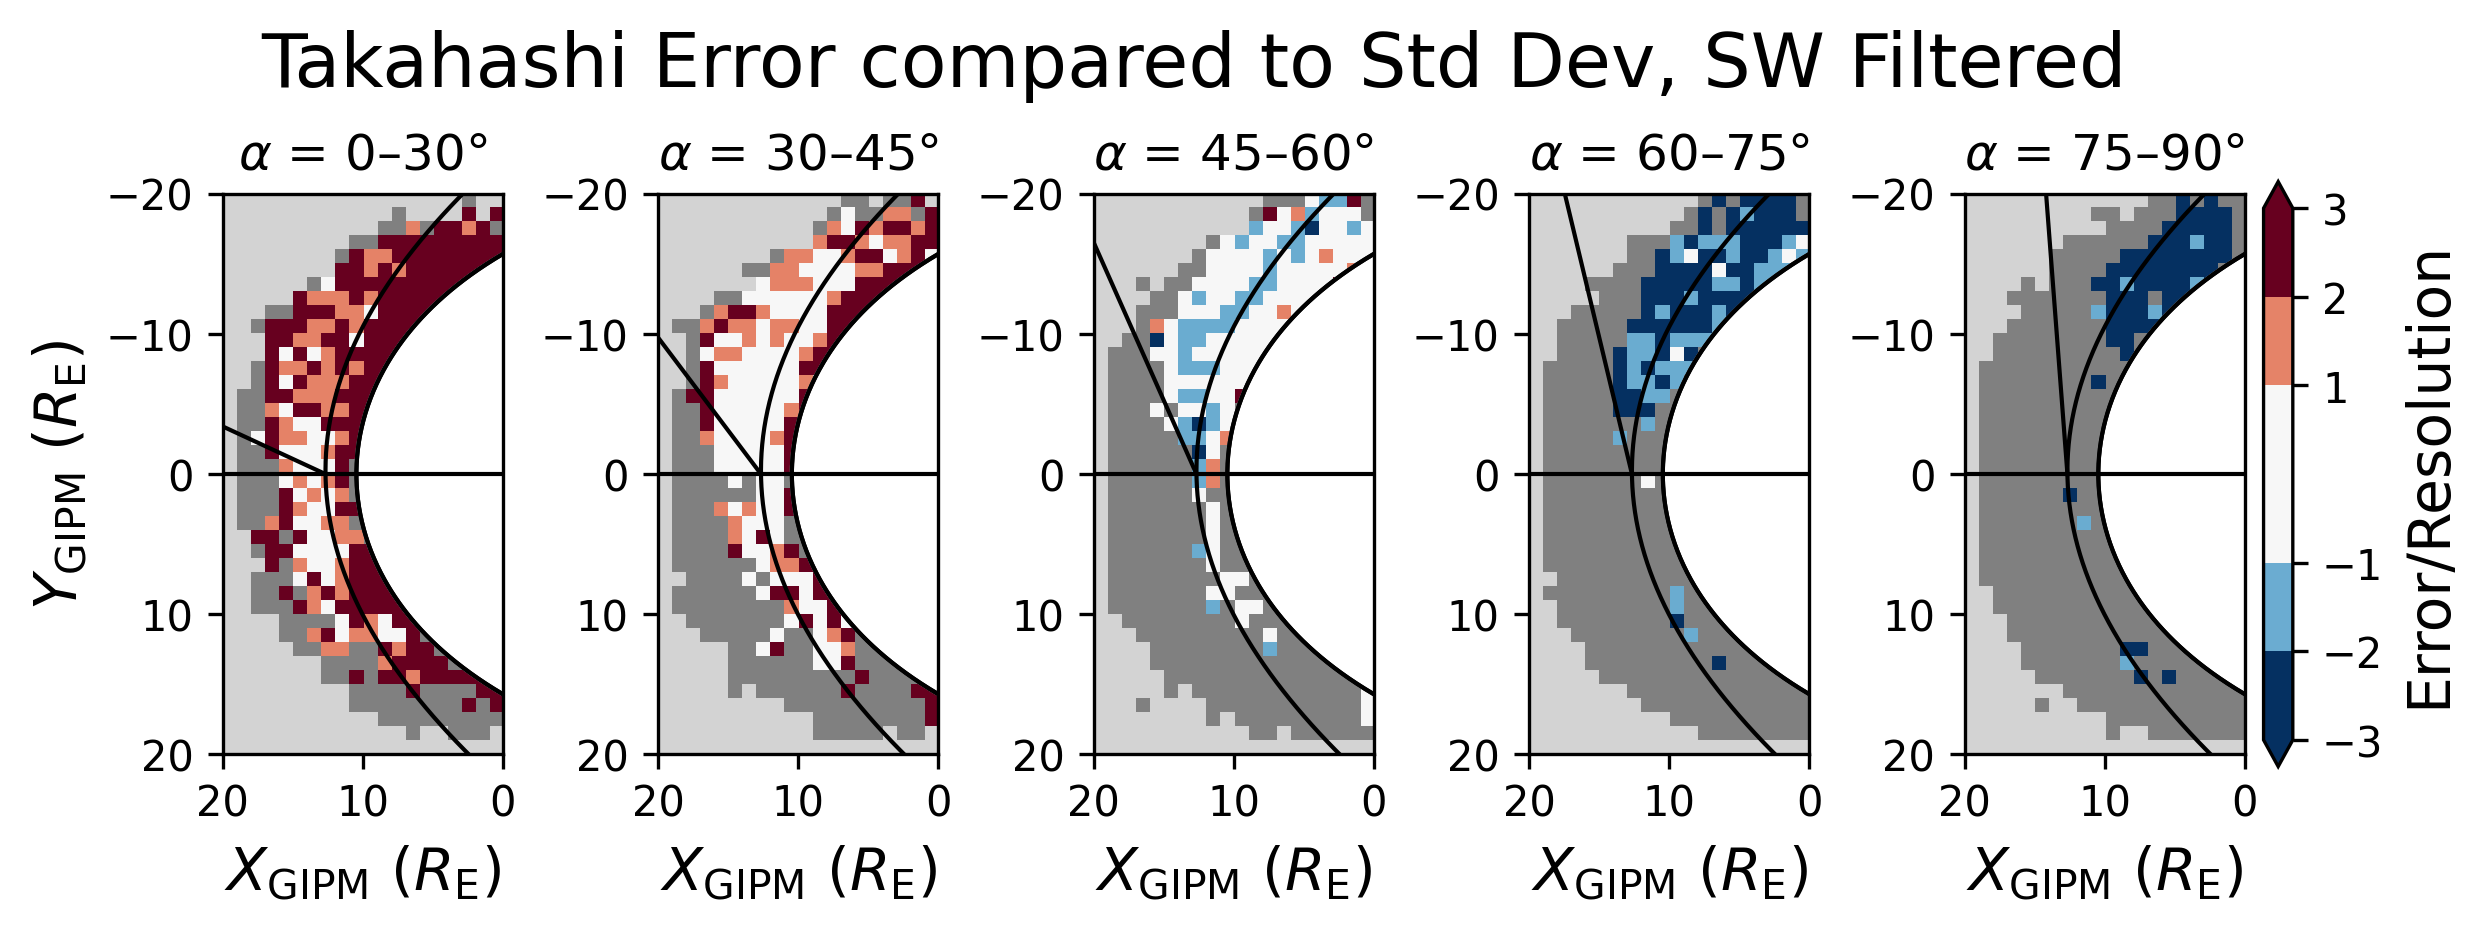

In [10]:
CA_Abs_Error_Plot('Takahashi Error compared to Std Dev, SW Filtered', tak_trans_error_over_std, filtered_heatmap_c , x_bin_edges, y_bin_edges)

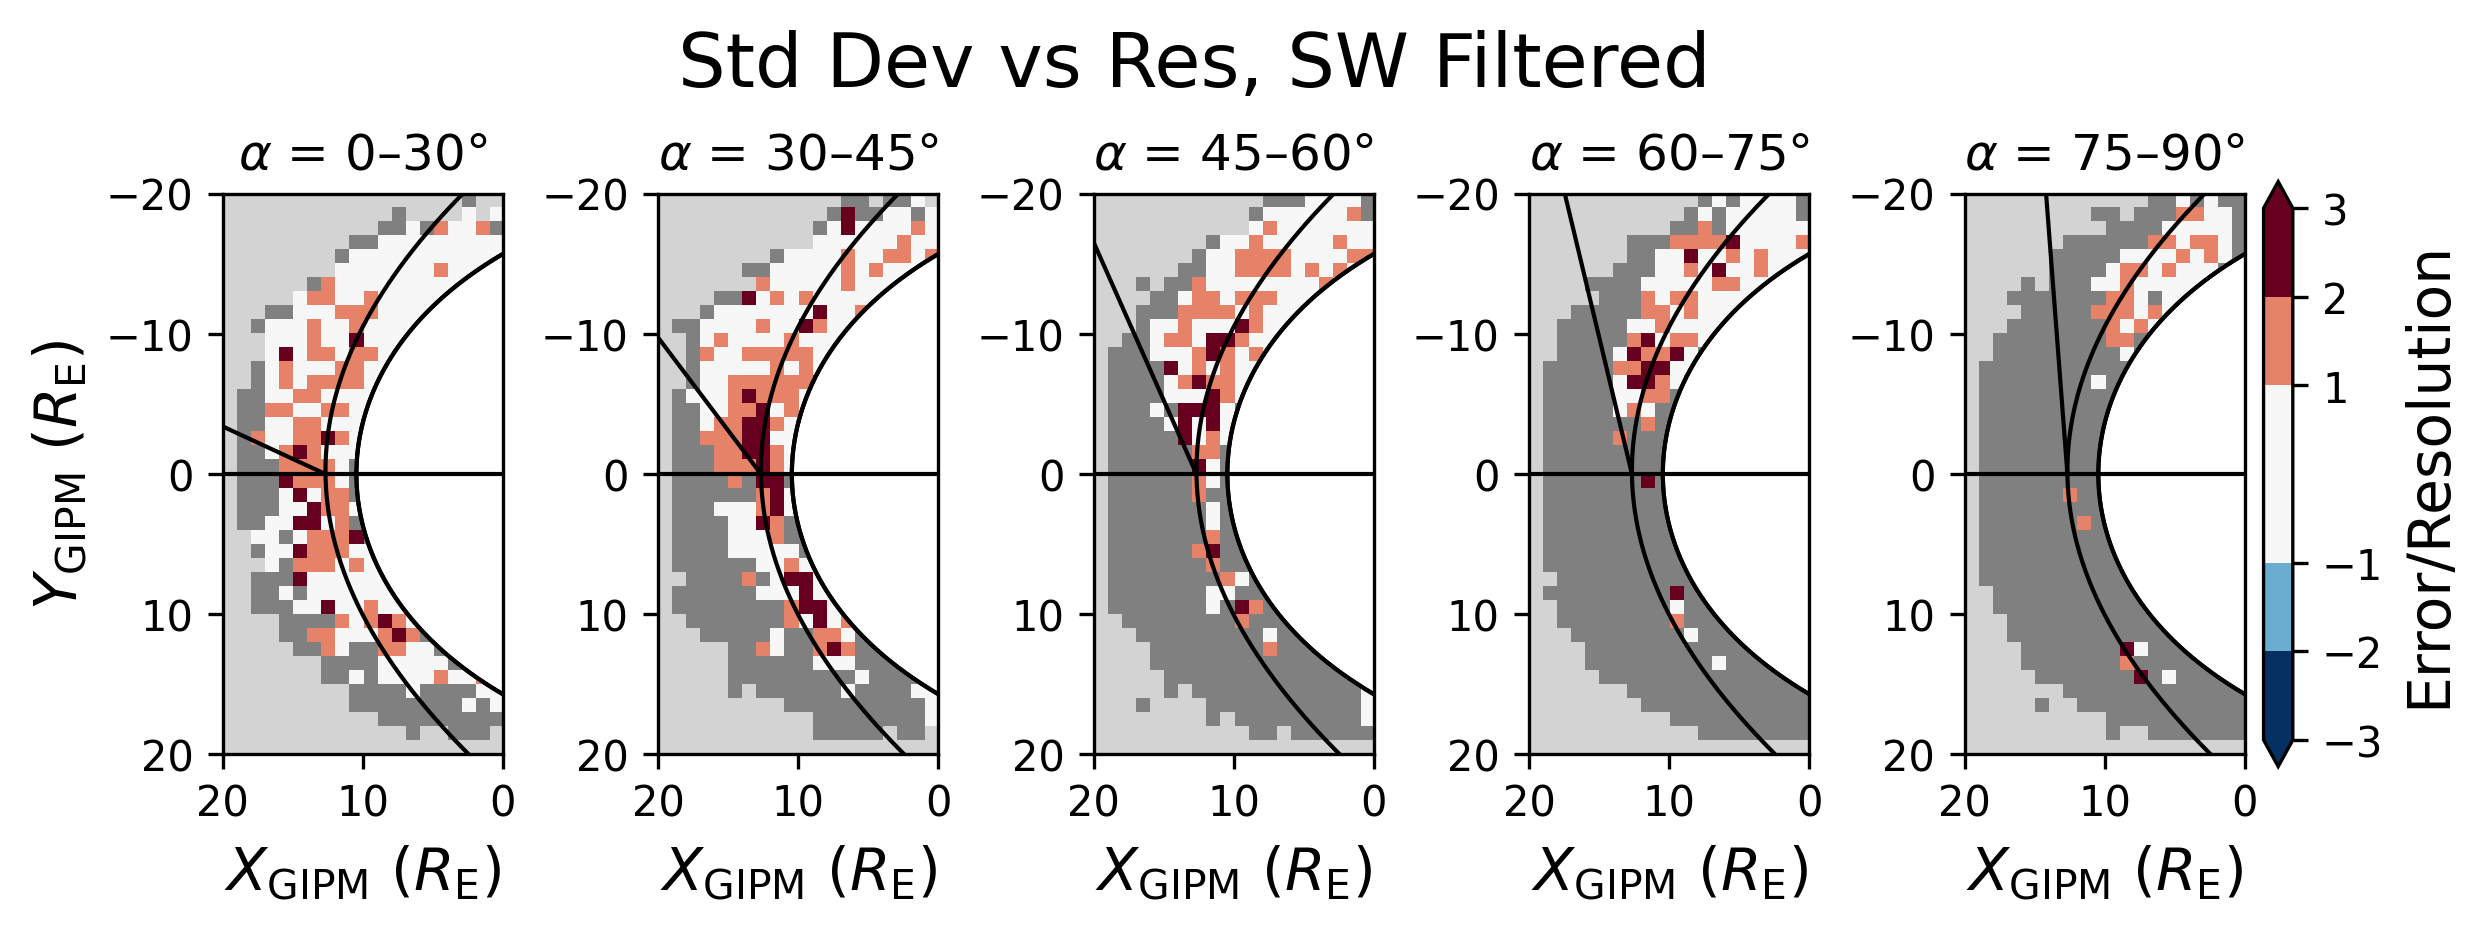

In [13]:
#Std error over resolution

std_hm = []

for hm in trans_std_dev_maps:
    hm_res = hm/(1/240)
    std_hm.append(hm_res)

CA_Abs_Error_Plot('Std Dev vs Res, SW Filtered', std_hm, filtered_heatmap_c , x_bin_edges, y_bin_edges)


In [7]:
from heatmap_modules import compute_hists2d
#df, metric, *keys, **choices
#'Transverse Power', 'Compressive Power', 'Compressibility', 'Compressive Frequency', 'Transverse Frequency', 'Ellipticity'
#'Takahashi Transverse Error/Resolution', 'Takahashi Compressive Error/Resolution', 'Heilig Transverse Error/Resolution'

heatmaps_dict_no_filt = {}

for group_name, df in CA_filtered_frames.items():
    heatmaps_dict_no_filt[group_name]= compute_hists2d(df, 'mean', 'Takahashi Transverse Error/Resolution', 'Takahashi Compressive Error/Resolution', obs_min=50)

filtered_heatmap_c = []
#set all non-NaN values to 1.5 for mapping purposes
for heatmap in heatmaps_dict_no_filt:
    heatmap[np.isnan(heatmap) == False] = 1.5
    filtered_heatmap_c.append(heatmap)

heatmaps_dict = {}

for group_name, df in CA_filtered_frames.items():
    #filtering
    df_ULF = df.loc[(df['ULF Band Normalised Transverse Power'] > 0.05)]
    #produce dicts
    heatmaps_dict[group_name]= compute_hists2d(df, 'mean', 'Takahashi Transverse Error/Resolution', 'Takahashi Compressive Error/Resolution', obs_min=50)
    

rad
lowspir
highspir
lowperp
highperp


In [3]:
heatmaps_dict['rad']['Takahashi Transverse Error/Resolution']

NameError: name 'heatmaps_dict' is not defined

In [ ]:


CA_Abs_Error_Plot('New Takahashi Transverse Error Over Resolution, SW Filtered', takahashi_trans_error_heatmap_ULF, filtered_heatmap_c , x_bin_edges, y_bin_edges)
CA_Abs_Error_Plot('New Takahashi Compressive Error Over Resolution, SW Filtered', takahashi_comp_error_heatmap_ULF, filtered_heatmap_c , x_bin_edges, y_bin_edges)
#CA_Abs_Error_Plot('Heilig Transverse Error Over Resolution, SW Filtered', heilig_trans_error_heatmap_ULF, filtered_heatmap_c , x_bin_edges, y_bin_edges)
